<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/fibona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fibonacci Performance Comparison: Recursive vs. Memoized

This notebook compares the performance of a naive recursive Fibonacci implementation against a memoized version. We will measure the execution time for various input sizes and visualize the results to highlight the efficiency gains from memoization.

In [23]:
import time
memo = {}

def fib_recursive(n):
    """Calculates the nth Fibonacci number using a naive recursive approach."""
    if n <= 1:
        return n
    return fib_recursive(n - 1) + fib_recursive(n - 2)

def fib_memo(a):
    """Calculates the nth Fibonacci number using recursion with memoization."""
    if a <= 1:
        return a
    if a in memo:
        return memo[a]
    result = fib_memo(a - 1) + fib_memo(a - 2)
    memo[a] = result
    return result


## Execution Timing
We will now run both Fibonacci implementations for a range of input sizes and record their execution times. The results will be stored in a string format that can be easily parsed for plotting.

In [24]:
import io

arr = [5, 10, 15, 20, 25, 30, 35]
output_lines = "n\tRecursive\t    Memoization\n"

for a in arr:
    start1 = time.perf_counter_ns()
    fib_recursive(a)
    end1 = time.perf_counter_ns()
    memo.clear()
    start2 = time.perf_counter_ns()
    fib_memo(a)
    end2 = time.perf_counter_ns()

    output_lines += f"{a}\t{end1 - start1}\t\t{end2 - start2}\n"


## Visualizing Performance
To better understand the performance difference, we will plot the execution times for both functions. A logarithmic scale will be used on the y-axis to effectively show the wide range of times, especially for the recursive function.

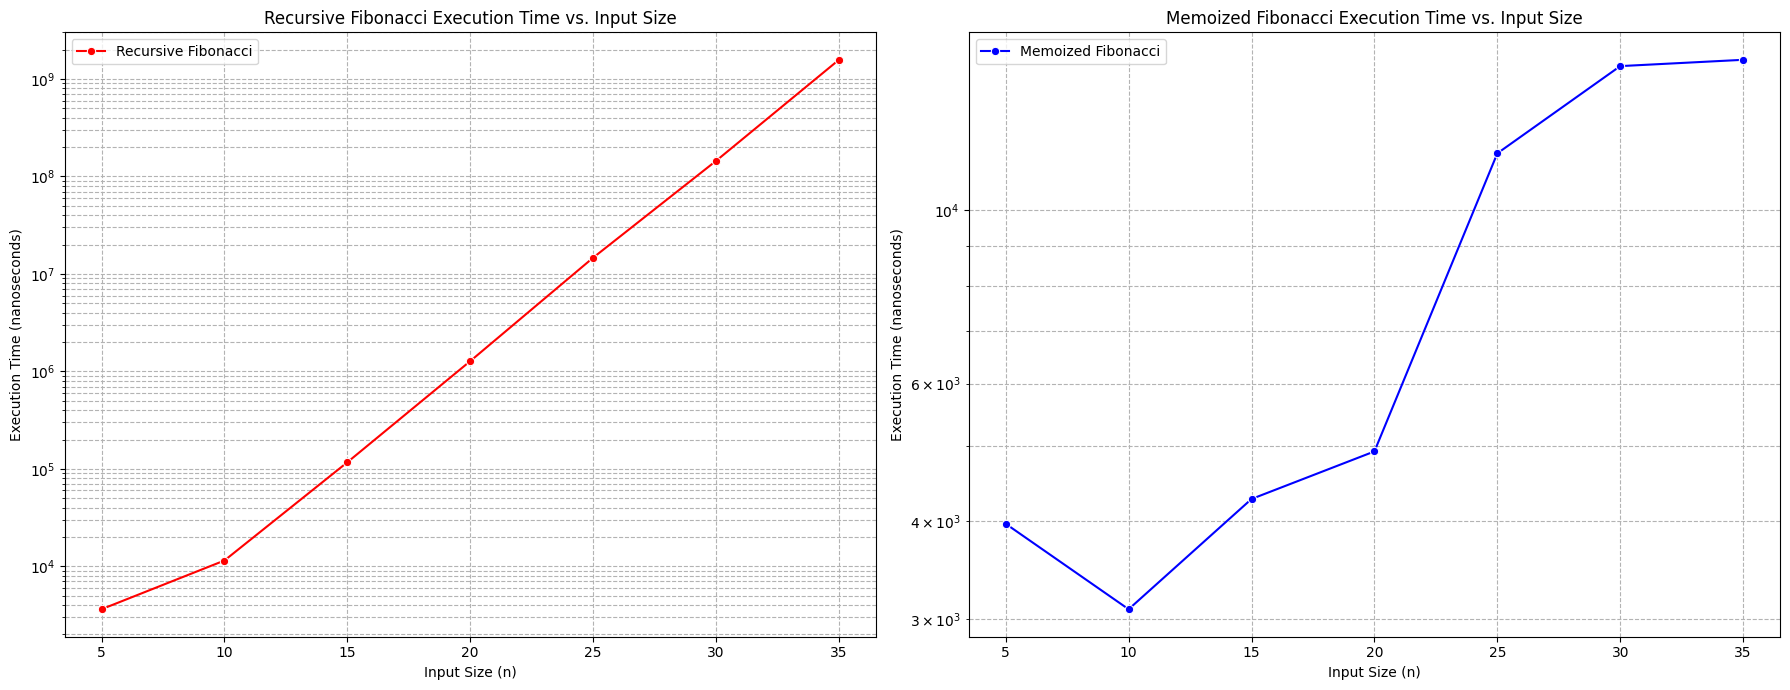

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io
data_io = io.StringIO(output_lines)
df_timing = pd.read_csv(data_io, sep=r'\s+')
df_timing.columns = df_timing.columns.str.strip()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.lineplot(x='n', y='Recursive', data=df_timing, marker='o', label='Recursive Fibonacci', ax=axes[0], color='red')
axes[0].set_title('Recursive Fibonacci Execution Time vs. Input Size')
axes[0].set_xlabel('Input Size (n)')
axes[0].set_ylabel('Execution Time (nanoseconds)')
axes[0].set_yscale('log')
axes[0].set_xticks(df_timing['n'])
axes[0].grid(True, which="both", ls="--", c='0.7')
axes[0].legend()

sns.lineplot(x='n', y='Memoization', data=df_timing, marker='o', label='Memoized Fibonacci', ax=axes[1], color='blue')
axes[1].set_title('Memoized Fibonacci Execution Time vs. Input Size')
axes[1].set_xlabel('Input Size (n)')
axes[1].set_ylabel('Execution Time (nanoseconds)')
axes[1].set_yscale('log')
axes[1].set_xticks(df_timing['n'])
axes[1].grid(True, which="both", ls="--", c='0.7')
axes[1].legend()

plt.tight_layout()
plt.show()